# 08 脚力を決める関数の形（中身はまだ等分）

## 背景

フェーズ 0 の最後である。[05](../docs/block-curriculum/05_Comparable_Planners.md) のとおり、予測最適化を後から足すには **同じ引数・同じ戻り** が要る。戻りは `Grf` 形状 \((4,3)\)。acados の \(u(24,)\) や LC の \(u(24)\) を下位へ直接渡さない。

この段の新しい現象は制御の中身ではなく **契約** である。中身はまだ EqualShare + 高さ P + 07 の小さい \(F_x\)。後の `LcNmpc` / `GrfMpc` もこの関数を実装する。

### 成功条件（数値。ここが合否）


**判定の更新（05 以降）:** 連続 hold は **10.0 s 以上**。歩く段はさらに水平 **10.0 m 以上**。ゲイトは PyMPC trot \(1.35\,\mathrm{Hz}/0.74\)、遊脚高さ \(5.6\)–\(8\,\mathrm{cm}\)（LC `swingHeight`）から大きく外さない。下の旧表（5.0 s、高い duty、数 mm リフト）は合格に使わない。旧セルと GIF は消さない。

| 量 | 条件 |
|---|---|
| `plan_grf(...)` の戻り | `shape==(4,3)`、立脚 \(F_z>0\)、遊脚行は \(0\) |
| 下位 | 05 と同じ \(\tau=h-J^{\top}F\) と遊脚 PD。`plan_grf` 以外から GRF を作らない |
| hold / 末尾 5 s / \(z\) / 姿勢 | 07 と同じ数値。連続 \(\ge 5.0\,\mathrm{s}\) |
| GIF | 指令 GRF は `plan_grf` の戻り |

満たすまでフェーズ 1 へ進まない。

## 目的

- 脚力の入口を一つにする
- 中身は等分のまま、5 秒の足踏み（微小 \(F_x\)）が契約を通っても動く

## 数式

```text
plan_grf(x, flags, schedule, ref) -> Grf (4,3)
```

今の中身:

$$
F_{z,i}=c_i\frac{mg+k_p(z^{ref}-z)-k_d\dot z}{n_s},\qquad
F_{x,i}=c_i\frac{F_x^{\mathrm{tiny}}}{n_s}
$$

## 仮説

1. 契約を通した GRF でも、07 と同じ 5 秒を満たす


In [1]:
# --- このセルの意図 ---
# 08: 脚力は plan_grf だけが返す。tau は戻り Grf を MapJT する。中身は等分。

from pathlib import Path
import sys
import numpy as np
import mujoco
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.plant.mujoco_go2 import MujocoGo2
from mpc_dog.viz.gif import render_rollout_gif

HOLD_S = 5.0
ATT_TOL = 0.35
Z_MIN = 0.20
T_RUN = 7.0
FREQ, DUTY = 1.0, 0.98
STEP_H = 0.02
KP_SW, KD_SW = 300.0, 20.0
KP_Z, KD_Z = 8000.0, 400.0
FX_TINY = 0.6
TROT_OFF = np.array([0.5, 1.0, 1.0, 0.5])

def longest_true_seconds(flags, dt):
    """内容: 連続 True の最長 [s]。"""
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best:
            best = cur
    return best * float(dt)

def clip_torque(tau, ctrl_range):
    """内容: 01 の飽和。"""
    u = np.asarray(tau, dtype=np.float64).reshape(-1)
    return np.clip(u, ctrl_range[:, 0], ctrl_range[:, 1])

def jac_leg(model, data, geoms, i):
    """内容: 脚 i の 3x3 足ヤコビ。"""
    J = np.zeros((3, model.nv))
    mujoco.mj_jacGeom(model, data, J, None, int(geoms[i]))
    return J[:, 6 + 3 * i : 9 + 3 * i]

def plan_grf(x, flags, schedule, ref):
    """意図: 後の NMPC と同じ引数。今の中身は EqualShare + 高さ P + 微小 Fx。
    内容: x[0]=z [m], x[1]=vz [m/s], x[2]=mass [kg]。flags=c(4,)。schedule は未使用。
    ref[0]=zref [m], ref[1]=Fx 合計 [N]。戻り Grf (4,3) [N]。遊脚行は 0。"""
    c = np.asarray(flags, dtype=np.float64).reshape(4)
    ns = max(float(c.sum()), 1.0)
    z, vz, mass = float(x[0]), float(x[1]), float(x[2])
    zref, fx_tot = float(ref[0]), float(ref[1])
    fz_tot = mass * 9.81 + KP_Z * (zref - z) - KD_Z * vz
    grf = np.zeros((4, 3), dtype=np.float64)
    for i in range(4):
        if c[i] > 0.5:
            grf[i, 0] = fx_tot / ns
            grf[i, 2] = fz_tot / ns
    return grf

# --- 契約の単体 ---
c_demo = np.array([1.0, 0.0, 0.0, 1.0])  # 内容: 対角立脚
G = plan_grf(np.array([0.29, 0.0, 15.21]), c_demo, None, np.array([0.29, FX_TINY]))
assert G.shape == (4, 3)
assert np.allclose(G[1], 0.0) and np.allclose(G[2], 0.0)
assert G[0, 2] > 0 and G[3, 2] > 0
print("contract ok", G)

def rollout():
    """内容: GRF は plan_grf だけ。tau は h - J^T F と遊脚 PD。"""
    p = MujocoGo2(scene="flat", seed=0)
    dt = p.sim_dt
    n = int(round(T_RUN / dt))
    geoms = p.foot_geom_ids()
    z0 = float(p.base_pos()[2])
    phi = TROT_OFF.copy()
    lift = p.feet_pos_world().copy()
    prev = np.ones(4)
    ok = []
    last_g = np.zeros((4, 3))
    for _k in range(n):
        phi = (phi + dt * FREQ) % 1.0
        c = (phi < DUTY).astype(float)
        z = float(p.base_pos()[2])
        vz = float(p.base_lin_vel_world()[2])
        x = np.array([z, vz, p.mass_kg])
        ref = np.array([z0, FX_TINY])
        grf = plan_grf(x, c, schedule=None, ref=ref)  # 内容: 契約どおり呼ぶ。下位は中を見ない
        last_g = grf
        feet = p.feet_pos_world()
        vel = p.feet_vel_world()
        h = np.asarray(p.data.qfrc_bias[6:], dtype=np.float64)
        tau = np.zeros(12)
        for i in range(4):
            if prev[i] > 0.5 and c[i] < 0.5:
                lift[i] = feet[i].copy()
            Jleg = jac_leg(p.model, p.data, geoms, i)
            sl = slice(3 * i, 3 * i + 3)
            if c[i] > 0.5:
                tau[sl] = h[sl] - Jleg.T @ grf[i]
            else:
                s = float(np.clip((phi[i] - DUTY) / max(1e-6, 1.0 - DUTY), 0.0, 1.0))
                w = FREQ / max(1e-6, 1.0 - DUTY)
                p_d = lift[i].copy()
                p_d[2] = lift[i, 2] + STEP_H * np.sin(np.pi * s)
                v_d = np.zeros(3)
                v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
                tau[sl] = Jleg.T @ (KP_SW * (p_d - feet[i]) + KD_SW * (v_d - vel[i]))
        p.step(clip_torque(tau, p.model.actuator_ctrlrange))
        prev = c
        rpy = p.base_rpy()
        z = float(p.base_pos()[2])
        ok.append(abs(rpy[0]) < ATT_TOL and abs(rpy[1]) < ATT_TOL and z > Z_MIN and bool(np.isfinite(p.data.qpos).all()))
    n5 = int(round(HOLD_S / dt))
    return {"hold": longest_true_seconds(ok, dt), "last5": bool(all(ok[-n5:])), "last_g": last_g, "n": n, "dt": dt}

r = rollout()
print("hold", r["hold"], "last5", r["last5"], "last_g", r["last_g"])
assert r["hold"] >= HOLD_S and r["last5"]
print("08 PASS: plan_grf contract ran", r["hold"], "s")


contract ok [[ 0.3      0.      74.60505]
 [ 0.       0.       0.     ]
 [ 0.       0.       0.     ]
 [ 0.3      0.      74.60505]]


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


hold 7.0 last5 True last_g [[ 0.15        0.         38.30732861]
 [ 0.15        0.         38.30732861]
 [ 0.15        0.         38.30732861]
 [ 0.15        0.         38.30732861]]
08 PASS: plan_grf contract ran 7.0 s


/home/takuya/work/mpc_dog/notebook/assets/08_planner_signature.gif 1951306 bytes


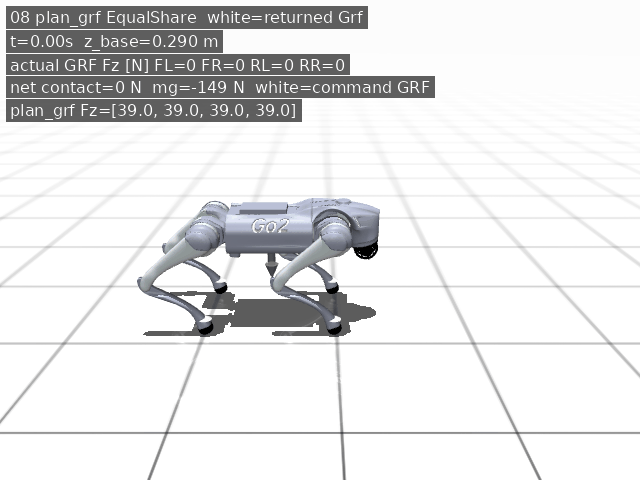

In [2]:
# --- このセルの意図 ---
# GIF: 白矢印は plan_grf の戻りそのもの。

st = {"phi": TROT_OFF.copy(), "prev": np.ones(4), "lift": None, "cmd": np.zeros((4, 3))}

def tau_fn(pl):
    """内容: rollout と同じ。command_grf に plan_grf を載せる。"""
    dt = pl.sim_dt
    if st["lift"] is None:
        st["lift"] = pl.feet_pos_world().copy()
        st["z0"] = float(pl.base_pos()[2])
    geoms = pl.foot_geom_ids()
    phi = (st["phi"] + dt * FREQ) % 1.0
    c = (phi < DUTY).astype(float)
    z = float(pl.base_pos()[2])
    vz = float(pl.base_lin_vel_world()[2])
    grf = plan_grf(np.array([z, vz, pl.mass_kg]), c, None, np.array([st["z0"], FX_TINY]))
    feet = pl.feet_pos_world()
    vel = pl.feet_vel_world()
    h = np.asarray(pl.data.qfrc_bias[6:], dtype=np.float64)
    tau = np.zeros(12)
    for i in range(4):
        if st["prev"][i] > 0.5 and c[i] < 0.5:
            st["lift"][i] = feet[i].copy()
        Jleg = jac_leg(pl.model, pl.data, geoms, i)
        sl = slice(3 * i, 3 * i + 3)
        if c[i] > 0.5:
            tau[sl] = h[sl] - Jleg.T @ grf[i]
        else:
            s = float(np.clip((phi[i] - DUTY) / max(1e-6, 1.0 - DUTY), 0.0, 1.0))
            w = FREQ / max(1e-6, 1.0 - DUTY)
            p_d = st["lift"][i].copy()
            p_d[2] = st["lift"][i, 2] + STEP_H * np.sin(np.pi * s)
            v_d = np.zeros(3)
            v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
            tau[sl] = Jleg.T @ (KP_SW * (p_d - feet[i]) + KD_SW * (v_d - vel[i]))
    st["phi"] = phi
    st["prev"] = c
    st["cmd"] = grf
    return clip_torque(tau, pl.model.actuator_ctrlrange)

plant = MujocoGo2(scene="flat", seed=0)
n_gif = int(round(T_RUN / plant.sim_dt))
path = render_rollout_gif(
    plant,
    Path("assets/08_planner_signature.gif"),
    n_steps=n_gif,
    capture_every=80,
    tau_fn=tau_fn,
    command_grf=lambda pl: st["cmd"],
    extra_lines=lambda pl: [f"plan_grf Fz={st['cmd'][:,2].round(0).tolist()}"],
    title="08 plan_grf EqualShare  white=returned Grf",
)
print(path.resolve(), path.stat().st_size, "bytes")
display(Image(filename=str(path)))


## 分析

戻りを `(4,3)` に固定した。中身は等分のまま 5 秒動いた。GIF `08_planner_signature.gif`。

フェーズ 0 はここまで。次は LC: 胴体指令とゲイト指令を別入力にする。


## 続き — 新判定では未成功

旧セルの hold 5 s と直立ループは、10 s / 10 m / 上流ゲイトの表では不合格である。05 が標準足踏みで 10 s 持つまで、この番号は進めない。失敗ログは残す。
